<a href="https://colab.research.google.com/github/bhargavi1973/machine-learning/blob/main/TwitterDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os

zip_file_path = '/content/archive (1).zip'
extract_dir = '/content/unzipped_archive'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' unzipped to '{extract_dir}'.")
print("Contents of the unzipped archive:")
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

'/content/archive (1).zip' unzipped to '/content/unzipped_archive'.
Contents of the unzipped archive:
/content/unzipped_archive/training.1600000.processed.noemoticon.csv


In [ ]:
import pandas as pd

file_path = '/content/unzipped_archive/training.1600000.processed.noemoticon.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')
display(df.head())

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [ ]:
df.columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']
display(df.head())

,sentiment,id,date,query,user,text
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [ ]:
sentiment_distribution = df['sentiment'].value_counts()
print("Distribution of 'sentiment' column:")
print(sentiment_distribution)

Distribution of 'sentiment' column:
sentiment
4    800000
0    799999
Name: count, dtype: int64


In [ ]:
# df = df.drop(columns=['id', 'date', 'query', 'user'])
display(df.head())

,sentiment,text
0,0,is upset that he can't update his Facebook by ...
1,0,@Kenichan I dived many times for the ball. Man...
2,0,my whole body feels itchy and like its on fire
3,0,"@nationwideclass no, it's not behaving at all...."
4,0,@Kwesidei not the whole crew


**Reasoning**:
To prepare the 'text' column for cleaning, I will create a new column 'cleaned_text' as a copy of 'text' and then convert all text in 'cleaned_text' to lowercase, followed by displaying the head of the DataFrame to verify the changes.



In [ ]:
df['cleaned_text'] = df['text'].copy()
df['cleaned_text'] = df['cleaned_text'].str.lower()
display(df.head())

,sentiment,text,cleaned_text
0,0,is upset that he can't update his Facebook by ...,is upset that he can't update his facebook by ...
1,0,@Kenichan I dived many times for the ball. Man...,@kenichan i dived many times for the ball. man...
2,0,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
3,0,"@nationwideclass no, it's not behaving at all....","@nationwideclass no, it's not behaving at all...."
4,0,@Kwesidei not the whole crew,@kwesidei not the whole crew


**Reasoning**:
The next step in text preprocessing is to remove URLs, mentions, and hashtags from the 'cleaned_text' column using regular expressions, as specified in the overall task.



In [ ]:
import re

def remove_patterns(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'@\w+', '', text) # Remove mentions
    text = re.sub(r'#\w+', '', text) # Remove hashtags
    return text

df['cleaned_text'] = df['cleaned_text'].apply(remove_patterns)
display(df.head())

,sentiment,text,cleaned_text
0,0,is upset that he can't update his Facebook by ...,is upset that he can't update his facebook by ...
1,0,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball. managed to s...
2,0,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
3,0,"@nationwideclass no, it's not behaving at all....","no, it's not behaving at all. i'm mad. why am..."
4,0,@Kwesidei not the whole crew,not the whole crew


**Reasoning**:
The next step in text preprocessing, according to the overall task, is to remove punctuation from the 'cleaned_text' column to further clean the text.



In [ ]:
import string

def remove_punctuation(text):
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

df['cleaned_text'] = df['cleaned_text'].apply(remove_punctuation)
display(df.head())

,sentiment,text,cleaned_text
0,0,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...
1,0,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sa...
2,0,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
3,0,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i he...
4,0,@Kwesidei not the whole crew,not the whole crew


**Reasoning**:
The next step in text preprocessing is to tokenize the text, remove stopwords, and lemmatize it using NLTK, as specified in the overall task. I'll start by downloading the necessary NLTK data.



In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
print("NLTK 'punkt', 'stopwords', and 'wordnet' corpora downloaded.")

NLTK 'punkt', 'stopwords', and 'wordnet' corpora downloaded.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

# Download the missing 'punkt_tab' resource
nltk.download('punkt_tab')

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def nltk_preprocess(text):
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(cleaned_tokens)

df['cleaned_text_nltk'] = df['cleaned_text'].apply(nltk_preprocess)
display(df[['text', 'cleaned_text', 'cleaned_text_nltk']].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,text,cleaned_text,cleaned_text_nltk
0,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...,upset cant update facebook texting might cry r...
1,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sa...,dived many time ball managed save 50 rest go b...
2,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire,whole body feel itchy like fire
3,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i he...,behaving im mad cant see
4,@Kwesidei not the whole crew,not the whole crew,whole crew


In [ ]:
display(df[['sentiment','cleaned_text_nltk']])

,sentiment,cleaned_text_nltk
0,0,upset cant update facebook texting might cry r...
1,0,dived many time ball managed save 50 rest go b...
2,0,whole body feel itchy like fire
3,0,behaving im mad cant see
4,0,whole crew
...,...,...
1599994,4,woke school best feeling ever
1599995,4,thewdbcom cool hear old walt interview â «
1599996,4,ready mojo makeover ask detail
1599997,4,happy 38th birthday boo alll time tupac amaru ...


In [ ]:
print(f"Total count of rows in the cleaned dataset: {df.shape[0]}")

Total count of rows in the cleaned dataset: 1599999


In [ ]:
print(df.isnull().sum())


sentiment            0
text                 0
cleaned_text         0
cleaned_text_nltk    0
dtype: int64


In [ ]:
display(df.head())

,sentiment,cleaned_text_nltk
0,0,upset cant update facebook texting might cry r...
1,0,dived many time ball managed save 50 rest go b...
2,0,whole body feel itchy like fire
3,0,behaving im mad cant see
4,0,whole crew


In [ ]:
print(df.columns)

Index(['sentiment', 'cleaned_text_nltk'], dtype='object')


In [ ]:
df['sentiment'] = df['sentiment'].replace(4, 1)
sentiment_distribution = df['sentiment'].value_counts()
print("Updated distribution of 'sentiment' column:")
print(sentiment_distribution)

Updated distribution of 'sentiment' column:
sentiment
1    800000
0    799999
Name: count, dtype: int64


In [ ]:
df

,sentiment,cleaned_text_nltk
0,0,upset cant update facebook texting might cry r...
1,0,dived many time ball managed save 50 rest go b...
2,0,whole body feel itchy like fire
3,0,behaving im mad cant see
4,0,whole crew
...,...,...
1599994,1,woke school best feeling ever
1599995,1,thewdbcom cool hear old walt interview â «
1599996,1,ready mojo makeover ask detail
1599997,1,happy 38th birthday boo alll time tupac amaru ...


In [ ]:
df.to_csv('twitter_sentiment_data.csv', index=False)
print("DataFrame saved to 'twitter_sentiment_data.csv'")

DataFrame saved to 'twitter_sentiment_data.csv'


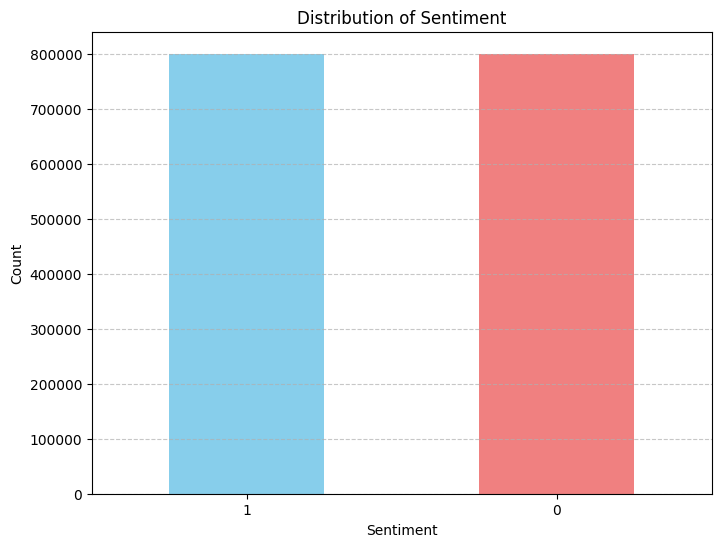

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sentiment_distribution.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Distribution of Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Based on the bar chart visualization of the sentiment distribution, we can draw the following conclusions:
# The dataset is highly balanced, with an almost equal number of instances for both sentiment '0' and sentiment '1'.
# This balanced distribution is beneficial for machine learning tasks, as it reduces the risk of the model being biased towards one particular sentiment class.